## Test Result Report

### Set directory path and turn off warnings

In [1]:
import os
import warnings

os.chdir("../../../../")
warnings.simplefilter(action='ignore', category=FutureWarning)

### Initialize SPARK connector

In [2]:
from data_quality.gx.plugins.connectors import SparkConnector

connector = SparkConnector()
connector.connect()

### Initialize </validation_results/> DataFrame

__Loading Delta Table from__ _validation_results/_ __folder__

In [3]:
from data_quality.gx.plugins.utils import load_test_result_report

tr_df = load_test_result_report(connector, connector.result_path)

### Create DataFrames for charts plotting

It is presumed that this report will be run after __scheduled__ _(data_quality/data_quality_scheduler.ipynb)_ Great Expectations notebook run.

In [4]:
from data_quality.gx.plugins.utils import apply_filters_and_get_multiple_dataframes

(
    df_back_days_range_run_over_run,
    df_latest_run,
    df,
    df_range_run_over_run,
    df_critical_issues
) = apply_filters_and_get_multiple_dataframes(tr_df, connector, 35)

### Variables for pie chart

In [5]:
from data_quality.gx.plugins.utils import set_pie_chart_variables

pie_chart_variables = set_pie_chart_variables(df, df_back_days_range_run_over_run)

### Pie Chart: Overall Amount of Passed Checks

The pie chart shows the distribution of passed Data Quality framework checks for a specific environment. It provides an overview of the total number of checks executed, along with the overall success percentage displayed in a separate text box on the right.

The chart also includes the run date and runtime. If the runtime is unavailable, it indicates that one or more checks were executed independently, so the exact runtime for the overall batch could not be determined.

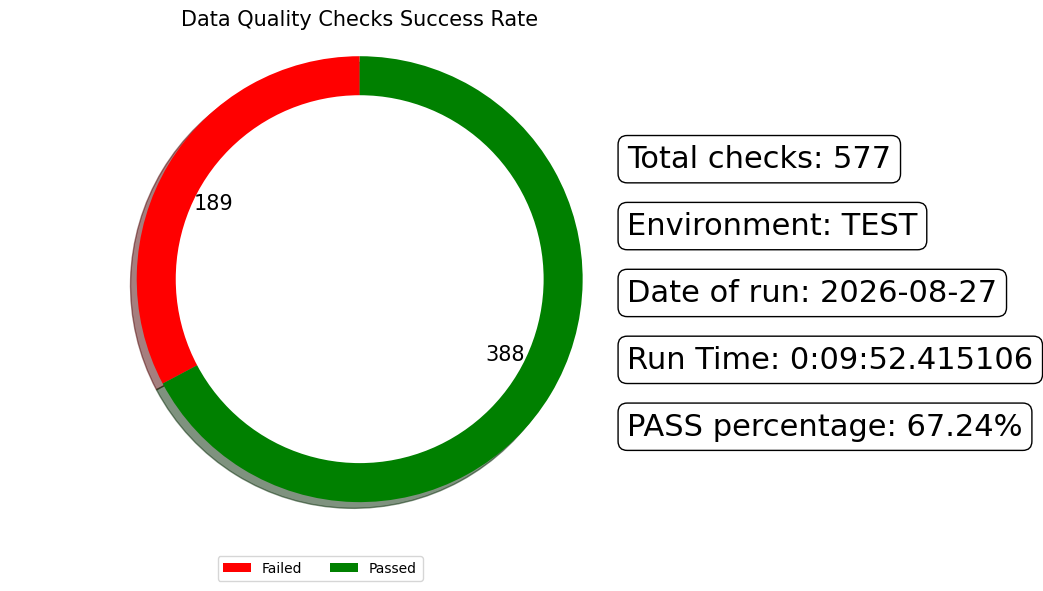

In [6]:
from data_quality.gx.plugins.utils import plot_success_percentage_pie_chart

plot_success_percentage_pie_chart(df, pie_chart_variables)

### Bar Chart: Passed Checks by Data Quality Dimension

The bar chart illustrates the percentage of passed checks for each Data Quality dimension across the different layers. The top of each bar represents the success rate of checks for a specific layer, while the total number of checks executed for that layer is displayed at the bottom.

The chart includes four Data Quality dimensions: "Completeness", "Integrity", "Uniqueness", and "Validity". A thin red line marks the 80% threshold, making it easy to identify layers that meet or exceed the desired pass rate.

The "Timeliness" dimension is not included, as it is not applicable to the predefined reference-data tables.

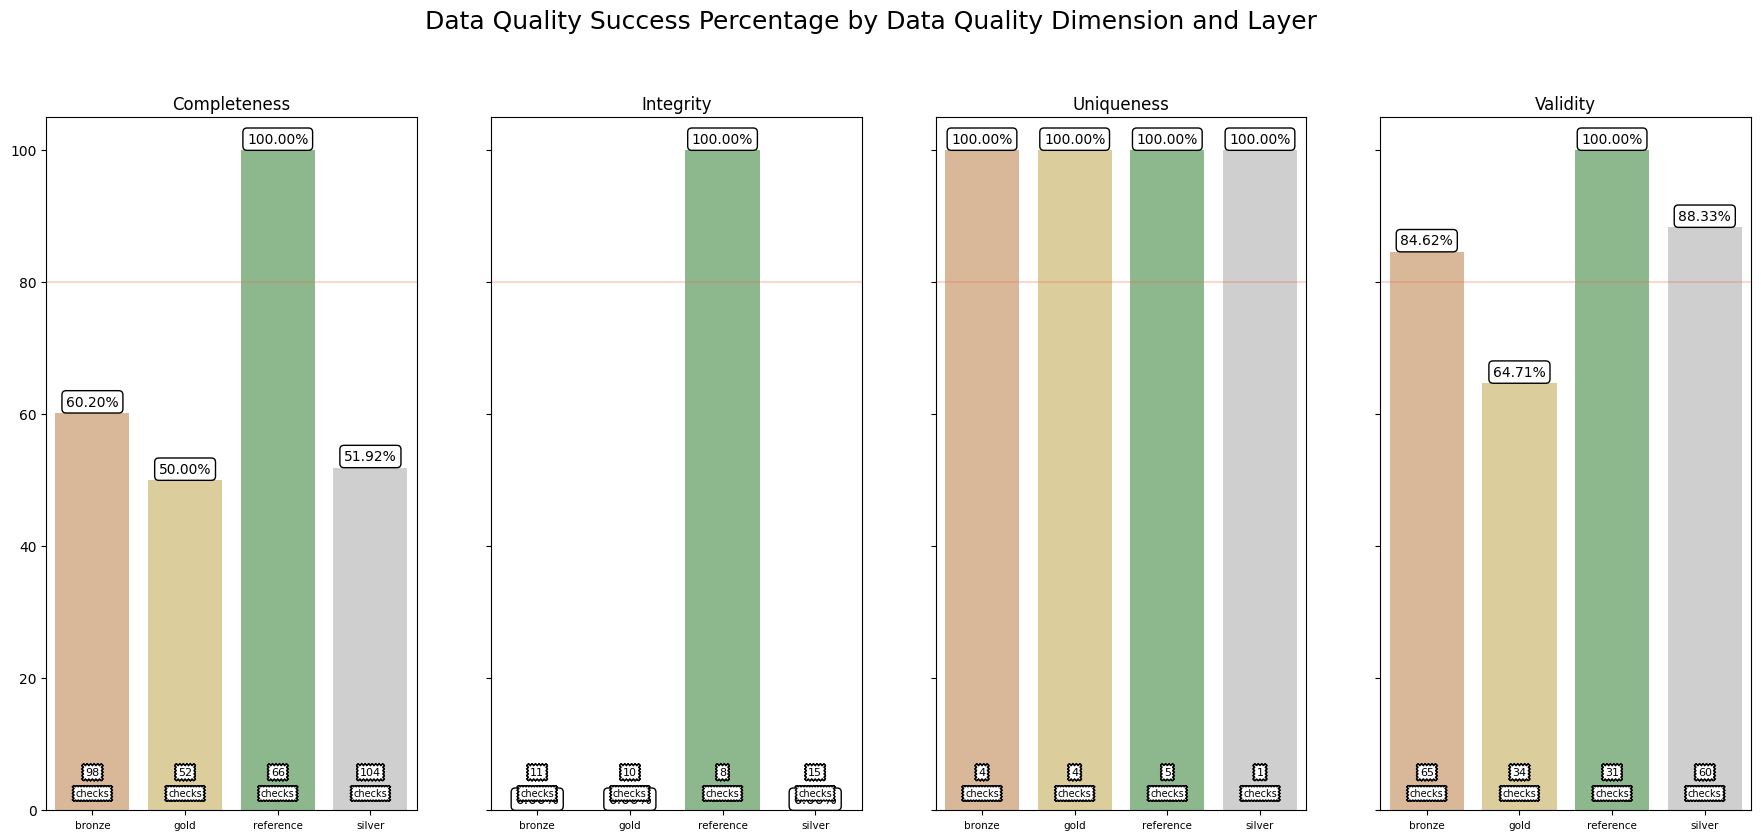

In [7]:
from data_quality.gx.plugins.utils import plot_success_percentage_bar_chart

plot_success_percentage_bar_chart(df)

### Heatmap: Check Success Percentage per Layer and Entity by Data Quality Dimension

The heatmap visually represents the percentage of successfully passed checks for each data entity across the different Data Quality dimensions.

The y-axis on the left displays the data entities, identified by a combination of the layer name and entity name. The x-axis represents the five Data Quality dimensions: "Completeness", "Integrity", "Timeliness", "Uniqueness", and "Validity".

Each cell shows the overall success percentage of the test suite for a specific data entity and Data Quality dimension. A color scale is used to indicate the success level, ranging from shades of red for lower success rates to shades of green for higher success rates. Different color intensities make it easy to compare the Data Quality performance across entities and dimensions.

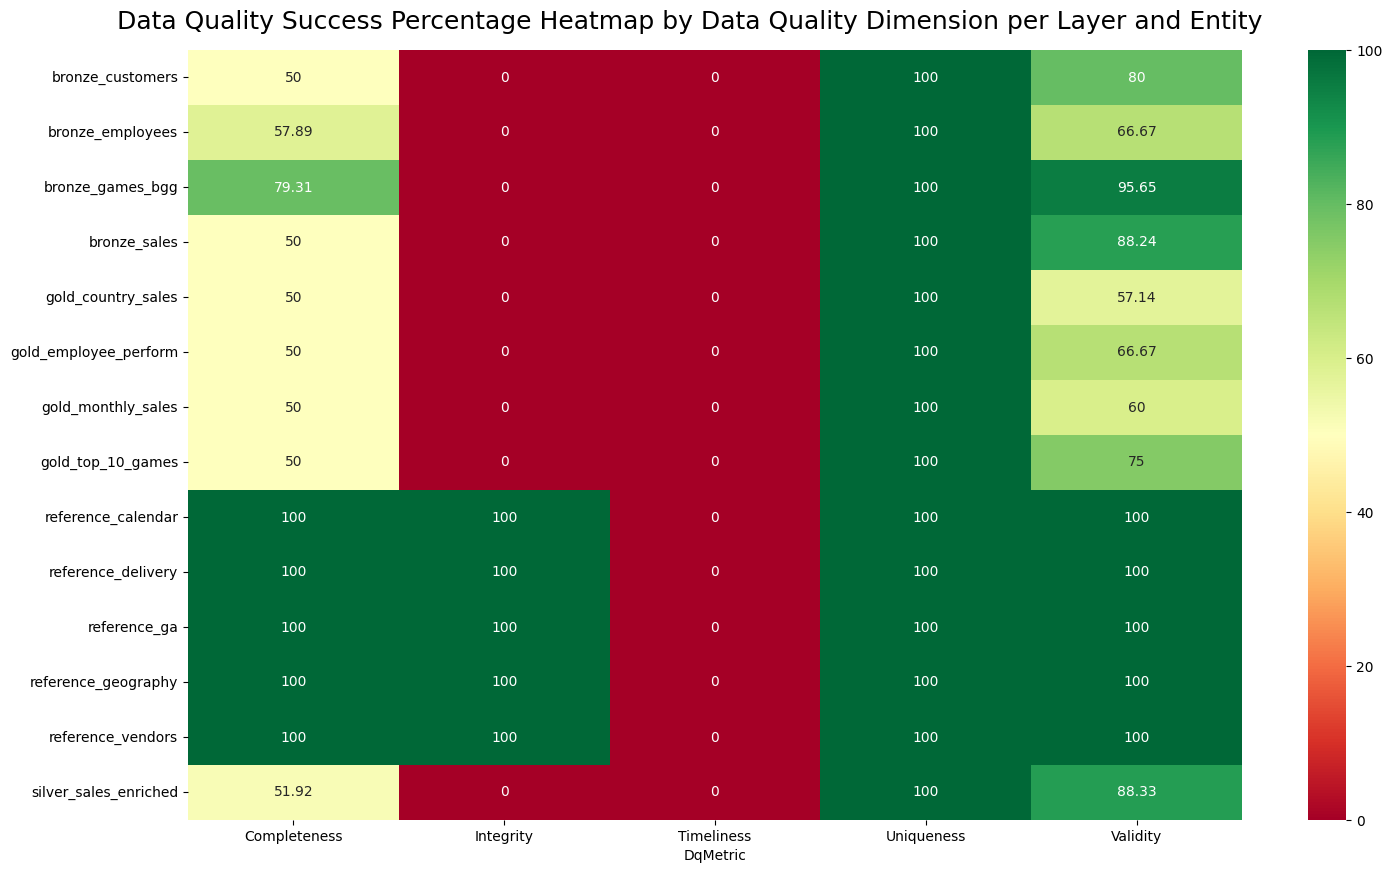

In [8]:
from data_quality.gx.plugins.utils import plot_success_percentage_heatmap

plot_success_percentage_heatmap(df)

In [ ]:
## barchars here

### Critical Data Quality Issues Table

The Critical Data Quality Issues Table provides a summary of failed critical Data Quality checks for existing data entities across different layers. It focuses only on critical checks that failed during the latest run and excludes custom metric checks. Each row represents a data entity and includes information about the failed check and the corresponding data layer.

The table includes the following predefined critical checks:

- __expect_column_values_to_be_unique__: Ensures that critical columns contain no duplicate values.
- __expect_compound_columns_to_be_unique__: Validates compound keys to prevent duplicate records.
- __expect_table_column_count_to_equal__: Verifies that the table contains the expected number of columns.
- __expect_table_row_count_to_be_between__: Validates row count thresholds to help ensure dataset completeness.
- __expect_column_to_exist__: Checks that required columns are present to maintain schema integrity.

These checks are associated with the _Completeness_ and _Uniqueness_ Data Quality dimensions.

The table is also color-coded to distinguish between different data processing and supporting layers:

- _gold_, _silver_, and _bronze_ represent different stages of data processing.
- reference-data represent auxiliary layers containing critical supporting datasets.

The table provides a quick overview of critical Data Quality issues, helping users identify failed checks, assess affected entities, and prioritize remediation efforts.

In [ ]:
from data_quality.gx.plugins.utils import plot_success_percentage_heatmap

plot_failed_dq_checks_table(df_critical_issues)